# Rainbow book P&L attribution — sticky-strike (the canonical study)

Daily P&L attribution of the daily-sold rainbow book (one \$1M 1Y 100/112
ranked-basket call spread per joint date, ~260 vintages at steady state),
computed entirely in the **sticky-strike** framework — the project's main
greeks path (decision 2026-08-06, verdict measured in `rainbow_greeks.ipynb`
§6: the SS delta hedge cuts hedged risk 43% vs the smile delta). The original
sticky-moneyness study is kept for historical reference as
`rainbow_attribution_sm.ipynb`.

Driver: `rainbow_attribution_ss` (CRN Sobol engine at the 512-path book
standard; cache `data/rainbow_attribution_ss.csv` via
`scripts/run_rainbow_attribution.py`, 515s on the GPU). Components — all
independent single-input revaluations off the t−1 close, sold-book sign,
fixed lookup TTM so term roll stays out of eq/vol:

| component | meaning |
|---|---|
| `eq` | all spots → t, sticky-strike: each index's implied distribution re-derived from its moneyness-shifted smile (vols pinned per strike) and its seasoning moved |
| `eq_delta/gamma/xgamma_*` | the eq move explained by the 1%-bump delta vector, gamma diagonal, and pair cross-gammas measured on the same book and CRN points; `eq_resid` = beyond-second-order |
| `vol`, `vol_<idx>` | surfaces → t **at fixed strikes** (day-t grids sampled at m/u), per-index singles; `vol_resid` = joint-move interaction |
| `cross_ev` | equity × vol cross by bumped revaluations (4-corner on the totals; eq and vol compose exactly — both applied = plain day-t tables) |
| `theta_value` | discount-factor decay on the base pv (zero revaluations) |
| `theta_delta` | per-vintage SS deltas × each vintage's forward-ratio decay over dt (the carry of the delta position) |
| `theta_gamma` | the rest of `time` (gamma theta + vol carry, folded per spec) |
| `fwd`, `rate` | forward curves re-read at t (r−q carry); USD discount-factor change |
| `resid` | `pl` minus everything above |

This notebook is analysis-only (it reads the cache); total runtime is printed
in the last cell.

In [1]:
import time
T0 = time.time()
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

r = pd.read_csv("data/rainbow_attribution_ss.csv", parse_dates=["date"],
                index_col="date")
NAMES = ("spx", "sx5e", "hsi")
print(f"{len(r)} date pairs, {r.index[0].date()} -> {r.index[-1].date()}, "
      f"book {r['n_pos'].iloc[-1]} positions | premium sold "
      f"${r['premium'].sum() / 1e6:.1f}M | final mark "
      f"${r['mark'].iloc[-1] / 1e6:.2f}M")

1968 date pairs, 2018-12-28 -> 2026-07-31, book 259 positions | premium sold $96.0M | final mark $-20.64M


             total $M  daily std $k  corr with pl
pl             -65.71        676.82          1.00
eq             -56.90        675.13          0.99
eq_delta       -52.12        683.69          0.99
eq_gamma        -8.00         34.84         -0.07
eq_xgamma        3.20         30.82         -0.01
eq_resid         0.03         14.02         -0.19
vol             -0.32         61.80         -0.00
vol_spx         -0.76         38.45         -0.04
vol_sx5e         0.68         29.30          0.02
vol_hsi         -0.47         16.55          0.05
vol_resid        0.23          1.82          0.06
cross_ev        -6.57         19.86         -0.27
time            -1.60         19.98          0.01
theta_value     -3.52          2.11          0.02
theta_delta      1.44          6.74         -0.06
theta_gamma      0.48         21.28          0.03
fwd              0.38         25.18          0.38
rate             0.02          2.80         -0.14
resid           -0.72          4.12          0.25


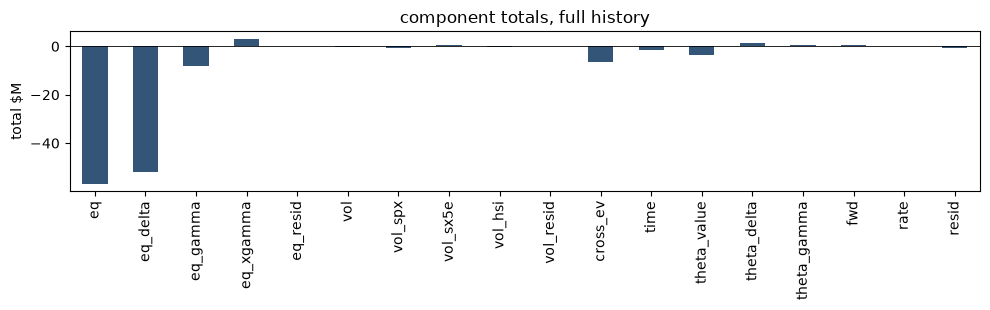

In [2]:
MAIN = ["pl", "eq", "eq_delta", "eq_gamma", "eq_xgamma", "eq_resid",
        "vol", "vol_spx", "vol_sx5e", "vol_hsi", "vol_resid", "cross_ev",
        "time", "theta_value", "theta_delta", "theta_gamma", "fwd", "rate",
        "resid"]
summ = pd.DataFrame({"total $M": r[MAIN].sum() / 1e6,
                     "daily std $k": r[MAIN].std() / 1e3,
                     "corr with pl": [np.corrcoef(r[c], r["pl"])[0, 1]
                                      for c in MAIN]})
print(summ.round(2).to_string())
fig, ax = plt.subplots(figsize=(10, 3.2))
(r[MAIN[1:]].sum() / 1e6).plot.bar(ax=ax, color="#357")
ax.set(ylabel="total $M", title="component totals, full history")
ax.axhline(0, color="k", lw=0.6)
plt.tight_layout()

Reading the table: the raw book lost **−\$65.7M** against \$96.0M of premium
sold — **−\$52.1M of it is `eq_delta`** (the unhedged short sticky-strike
delta into a rising market; the smile-delta cut of the legacy study assigned
−\$54.5M — the ~\$2.4M gap is the smile-slide vega term that framework
borrows into delta). The systematic non-delta drags: `eq_gamma` **−\$8.0M**
(the short-gamma cost of crash days), `cross_ev` **−\$6.6M** (the spot×vol
drag — the vanna line of the vanilla book, here measured by bumped
revaluations), and `theta_value` −\$3.5M of financing, partly offset by
`eq_xgamma` **+\$3.2M** — of which +\$3.24M is the SPX–SX5E pair alone
(the rank-kink cross-gamma of `rainbow_greeks.ipynb`, showing up in realized
P&L; the HSI pairs net ±\$0.2M). Net `vol` is small (−\$0.3M) with
offsetting singles and a tiny interaction residual (std \$1.8k).

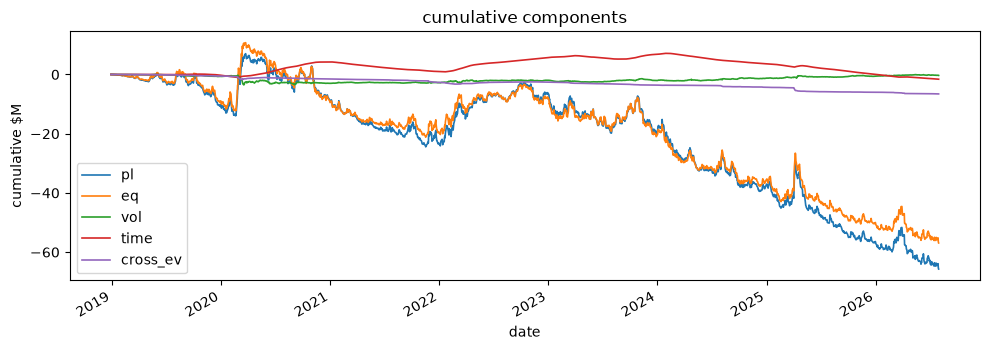

In [3]:
fig, ax = plt.subplots(figsize=(10, 3.6))
for c in ["pl", "eq", "vol", "time", "cross_ev"]:
    (r[c].cumsum() / 1e6).plot(ax=ax, lw=1.2, label=c)
ax.legend()
ax.set(ylabel="cumulative $M", title="cumulative components")
plt.tight_layout()

## The delta-hedged book — the desk view

The headline series is what the option desk actually keeps after delta
hedging: `pl − eq_delta − theta_value − theta_delta`. Piece by piece: the
delta P&L is hedged away (`eq_delta`); the interest on the option's market
value (`theta_value`, −\$3.5M) was never the desk's — it accrues to the
treasury desk against the premium cash; and `theta_delta` (+\$1.4M) is the
forward-roll gain on the option position that exactly pays the delta-one
desk's funding charge on the hedge (equivalently, a futures hedge earns spot
return minus forward drift, cancelling it). The only theta the desk keeps is
**`theta_gamma`** — genuine option risk. This matches the vanilla thread's
convention, where `time_funding` (= these two pieces, unsplit) was likewise
excluded from the delta-hedged view. The small remainder (`eq_resid`,
`rate`, `resid`) is grouped as *other*; everything sums to the black total.


excluded carry: theta_value -3.52M (treasury) + theta_delta +1.44M (pays the delta funding) = -2.08M
                          total $M  std $k  median $  skew  worst $M
desk delta-hedged           -11.51   94.05  -2467.25 -6.22     -1.47
after delta+gamma matrix     -6.70   67.54  -4577.35 -0.89     -0.84


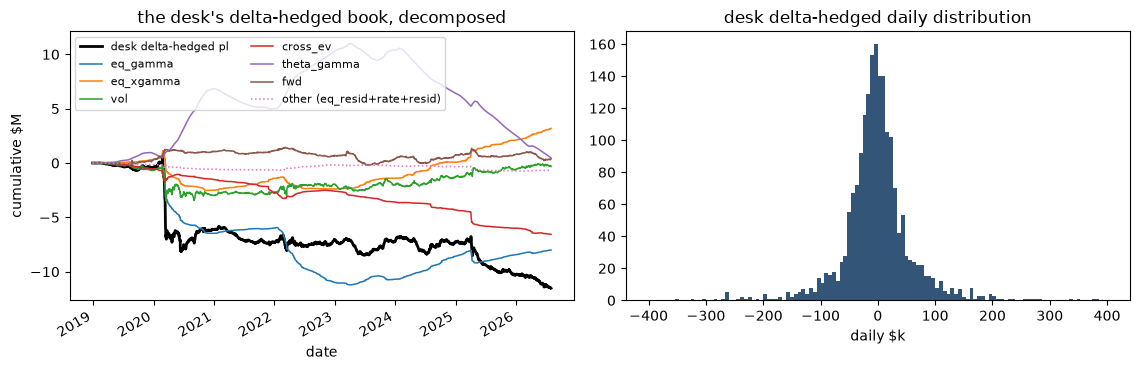

In [4]:
h = r["pl"] - r[["eq_delta", "theta_value", "theta_delta"]].sum(axis=1)
hg = h - r["eq_gamma"] - r["eq_xgamma"]
comps = ["eq_gamma", "eq_xgamma", "vol", "cross_ev", "theta_gamma",
         "fwd"]
other = h - r[comps].sum(axis=1)                  # eq_resid + rate + resid
fig, ax = plt.subplots(1, 2, figsize=(11.5, 3.8))
(h.cumsum() / 1e6).plot(ax=ax[0], color="k", lw=2,
                        label="desk delta-hedged pl")
for c in comps:
    (r[c].cumsum() / 1e6).plot(ax=ax[0], lw=1.1, label=c)
(other.cumsum() / 1e6).plot(ax=ax[0], lw=1.1, ls=":",
                            label="other (eq_resid+rate+resid)")
ax[0].legend(fontsize=8, ncol=2)
ax[0].set(ylabel="cumulative $M",
          title="the desk's delta-hedged book, decomposed")
ax[1].hist(h / 1e3, bins=120, range=(-400, 400), color="#357")
ax[1].set(xlabel="daily $k", title="desk delta-hedged daily distribution")
plt.tight_layout()
carry = r["theta_value"] + r["theta_delta"]
print(f"excluded carry: theta_value {r['theta_value'].sum() / 1e6:+.2f}M "
      f"(treasury) + theta_delta {r['theta_delta'].sum() / 1e6:+.2f}M "
      f"(pays the delta funding) = {carry.sum() / 1e6:+.2f}M")
print(pd.DataFrame({"total $M": [h.sum() / 1e6, hg.sum() / 1e6],
                    "std $k": [h.std() / 1e3, hg.std() / 1e3],
                    "median $": [h.median(), hg.median()],
                    "skew": [h.skew(), hg.skew()],
                    "worst $M": [h.min() / 1e6, hg.min() / 1e6]},
                   index=["desk delta-hedged", "after delta+gamma matrix"])
      .round(2).to_string())


The desk's delta-hedged book loses **−\$11.5M** over the sample at \$94k
daily std (median −\$2.5k/day; the carry-inclusive cut `pl − eq_delta` is
−\$13.6M at the same std — excluding the −\$2.1M of deterministic carry
moves the level, not the risk): with the market beta properly removed, the
short book's systematic costs — crash gamma, the spot×vol drag — are no
longer subsidised by hidden delta. After the gamma matrix the residual is
\$67k std with skew −0.9 (vs −6.2 delta-only): the crash left tail is
almost entirely second-order equity risk, explained by the same 19 pricings
that produce the hedge.

## How good is the 1%-bump Taylor across seven years?


eq_resid: cumulative $+0.03M over 1968 days | std $14,020 (2.1% of pl std) | big-day std $53,206 | worst $320,174 on 2020-03-17
xgamma by pair ($M): {'spx_sx5e': 3.24, 'spx_hsi': -0.21, 'sx5e_hsi': 0.17}


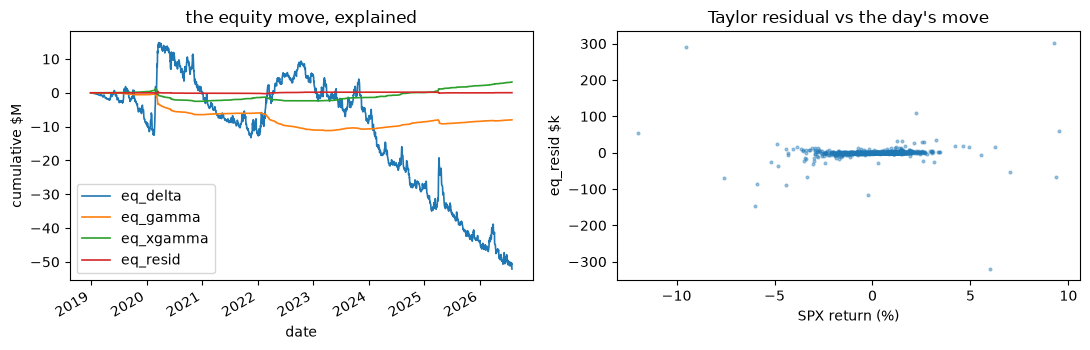

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
for c in ["eq_delta", "eq_gamma", "eq_xgamma", "eq_resid"]:
    (r[c].cumsum() / 1e6).plot(ax=ax[0], lw=1.2, label=c)
ax[0].legend()
ax[0].set(ylabel="cumulative $M", title="the equity move, explained")
ax[1].scatter(100 * r["ret_spx"], r["eq_resid"] / 1e3, s=4, alpha=0.4)
ax[1].set(xlabel="SPX return (%)", ylabel="eq_resid $k",
          title="Taylor residual vs the day's move")
plt.tight_layout()
big = r["ret_spx"].abs() > 0.02
print(f"eq_resid: cumulative ${r['eq_resid'].sum() / 1e6:+.2f}M over "
      f"{len(r)} days | std ${r['eq_resid'].std():,.0f} "
      f"({r['eq_resid'].std() / r['pl'].std():.1%} of pl std) | "
      f"big-day std ${r.loc[big, 'eq_resid'].std():,.0f} | worst "
      f"${r['eq_resid'].abs().max():,.0f} on "
      f"{r['eq_resid'].abs().idxmax().date()}")
print("xgamma by pair ($M):",
      {k.replace('eq_xgamma_', ''): round(v / 1e6, 2)
       for k, v in r[[c for c in r.columns
                      if c.startswith('eq_xgamma_')]].sum().items()})

Remarkably well: the residual beyond delta+gamma+cross totals **+\$0.03M
over 7.6 years** — the 1%-window matrix neither leaks nor drifts — with std
\$14k (2% of P&L std). It is a big-move phenomenon only (cubic shape in the
scatter, worst \$320k on 2020-03-17's ±10% chaos, big-day std \$53k), which
is exactly what a second-order model should leave behind.

## Vol at fixed strikes, and the theta split

theta means $k/day: {'theta_value': -1.79, 'theta_delta': 0.73, 'theta_gamma': 0.24}


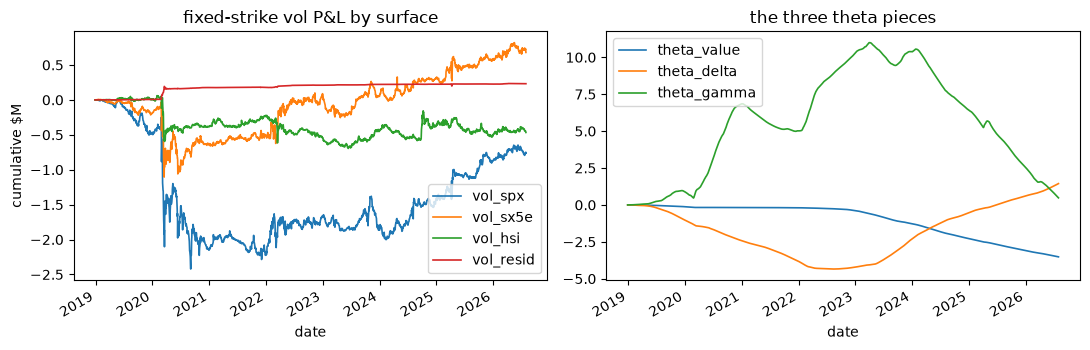

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
for c in ["vol_spx", "vol_sx5e", "vol_hsi", "vol_resid"]:
    (r[c].cumsum() / 1e6).plot(ax=ax[0], lw=1.2, label=c)
ax[0].legend()
ax[0].set(ylabel="cumulative $M", title="fixed-strike vol P&L by surface")
for c in ["theta_value", "theta_delta", "theta_gamma"]:
    (r[c].cumsum() / 1e6).plot(ax=ax[1], lw=1.2, label=c)
ax[1].legend()
ax[1].set(title="the three theta pieces")
plt.tight_layout()
print("theta means $k/day:",
      (r[["theta_value", "theta_delta", "theta_gamma"]].mean() / 1e3)
      .round(2).to_dict())

Fixed-strike vol is a wash in total (SPX −\$0.8M, SX5E +\$0.7M, HSI −\$0.5M
— HSI again the biggest single-surface drag at the smallest std) and the
interaction residual is negligible. The theta pieces: `theta_value` is the
steady −\$1.8k/day financing line (−\$3.5M total, rate-regime shaped),
`theta_delta` +\$0.7k/day (forward-drift carry of the short-delta position),
and `theta_gamma` — small in total (+\$0.5M) but \$21k daily std — is the
live gamma-theta line that pairs against `eq_gamma`'s crash losses.

## COVID, day by day

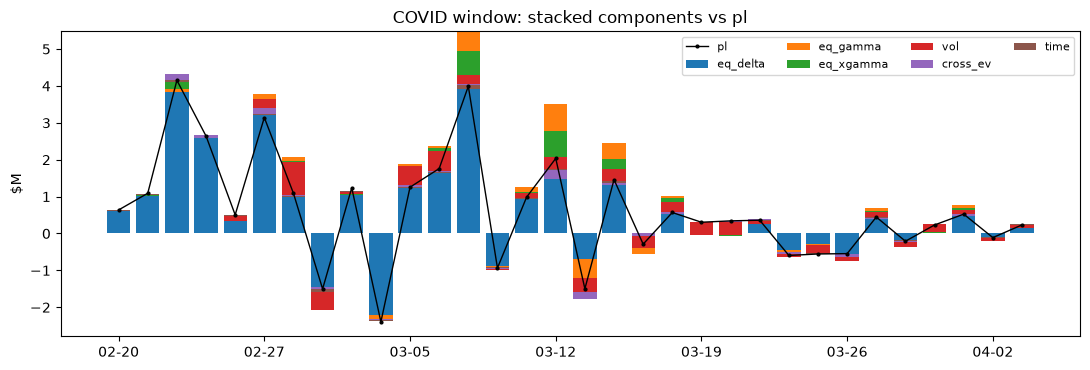

In [7]:
w = r.loc["2020-02-20":"2020-04-03",
          ["eq_delta", "eq_gamma", "eq_xgamma", "vol", "cross_ev", "time"]]
fig, ax = plt.subplots(figsize=(11, 3.8))
bot = np.zeros(len(w))
for c in w.columns:
    ax.bar(range(len(w)), w[c] / 1e6, bottom=bot, label=c, width=0.8)
    bot += w[c] / 1e6
ax.plot(range(len(w)), r.loc[w.index, "pl"] / 1e6, "k.-", lw=1, ms=4,
        label="pl")
ax.set_xticks(range(0, len(w), 5))
ax.set_xticklabels([d.strftime("%m-%d") for d in w.index[::5]])
ax.legend(fontsize=8, ncol=4)
ax.set(ylabel="$M", title="COVID window: stacked components vs pl")
plt.tight_layout()

In [8]:
tay = r[["eq_delta", "eq_gamma", "eq_xgamma", "eq_resid"]].sum(axis=1)
th = r[["theta_value", "theta_delta", "theta_gamma"]].sum(axis=1)
top = r[["eq", "vol", "cross_ev", "time", "fwd", "rate", "resid"]].sum(axis=1)
assert np.allclose(tay, r["eq"], atol=1e-6)
assert np.allclose(th, r["time"], atol=1e-6)
assert np.allclose(top, r["pl"], atol=1e-6)
print(f"identities exact | resid std ${r['resid'].std():,.0f} = "
      f"{r['resid'].std() / r['pl'].std():.2%} of pl std, worst "
      f"${r['resid'].abs().max():,.0f} on {r['resid'].abs().idxmax().date()}")
print("\nworst-|resid| days:")
cols = ["pl", "eq", "vol", "cross_ev", "time", "resid", "ret_spx"]
print(r.reindex(r["resid"].abs().sort_values(ascending=False).index[:5])[cols]
      .round(0).to_string())

identities exact | resid std $4,122 = 0.61% of pl std, worst $94,047 on 2020-03-09

worst-|resid| days:
                   pl         eq       vol  cross_ev      time    resid  ret_spx
date                                                                            
2020-03-09  3991225.0  4227747.0 -239454.0 -131520.0   99783.0 -94047.0     -0.0
2022-01-24  1793609.0  1879220.0  -33053.0  -61621.0   17518.0  40569.0      0.0
2020-02-24  4152626.0  4188328.0   58041.0 -159927.0  -48902.0  38787.0     -0.0
2022-03-07  1178264.0  1190841.0 -139323.0   29427.0  102463.0 -37111.0     -0.0
2025-05-12 -2613657.0 -2426560.0  -44364.0  -48780.0  -24143.0 -30286.0      0.0


## Takeaways

- The sticky-strike cut is now the canonical attribution: the delta line is
  the hedge that was measured to cut hedged risk 43%, and the equity move is
  explained down to a \$14k-std, zero-drift residual by the same 1%-bump
  delta/gamma/cross matrix the hedging and VaR work uses.
- The book's economics under the honest hedge: −\$11.5M desk delta-hedged
  (the −\$2.1M of financing + delta carry is excluded — it belongs to
  treasury and the delta-one funding bill), driven by crash gamma (−\$8.0M)
  and the spot×vol cross (−\$6.6M), partly offset by the rank pair's
  cross-gamma (+\$3.2M) — every one of these a *measured bump quantity*,
  not a formula.
- Top-level residual std \$4.1k = 0.61% of P&L std — identical quality to
  the legacy sticky-moneyness driver, so nothing was lost in the re-cut.
- Next: the cheap-VaR benchmark on this book — the bump matrix here is
  exactly the greeks side of that comparison.


In [9]:
print(f"total notebook runtime: {time.time() - T0:.1f}s (analysis-only; "
      f"the 515s of GPU compute lives in scripts/run_rainbow_attribution.py)")

total notebook runtime: 1.9s (analysis-only; the 515s of GPU compute lives in scripts/run_rainbow_attribution.py)
